<a href="https://colab.research.google.com/github/ViacheslavPomazan/Analysis_of_A-B_test_results--Google_Colab_and_Tableau_Project/blob/main/ab_test_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#A/B testing results report

###The goal of testing is to determine whether the new design improved various user behavior metrics.

**Research Hypotheses.**<br>Since we expect the new design to have a positive impact on user engagement and performance, one-tailed tests are used for all metrics.<br>
1. Conversion Rate (CR)<br>
* Null Hypothesis (H0): The new design had no effect on the conversion rate or led to a decrease.<br>
* Alternative Hypothesis (H1): The new design led to a statistically significant increase in the conversion rate.<br>
2. Average Session Duration<br>
* Null Hypothesis (H0): The average session duration in the test group remained unchanged or decreased compared to the control group.<br>
* Alternative Hypothesis (H1): The new design led to a statistically significant increase in the average session duration.<br>
3. Average Visited Pages<br>
* Null Hypothesis (H0): The average number of pages viewed per session remained unchanged or decreased.<br>
* Alternative Hypothesis (H1): The new design led to a statistically significant increase in the average number of visited pages.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/ab_test_results.csv")
df.head()

Mounted at /content/drive


,user_id,variant,converted,session_duration,pages_visited,age
0,1,control,0,3.494324,7,57
1,2,treatment,0,4.452306,4,24
2,3,control,0,4.384545,1,49
3,4,control,0,6.338822,6,36
4,5,control,0,1.576521,3,23


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  int64  
 1   variant           10000 non-null  object 
 2   converted         10000 non-null  int64  
 3   session_duration  10000 non-null  float64
 4   pages_visited     10000 non-null  int64  
 5   age               10000 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
df.describe()

,user_id,converted,session_duration,pages_visited,age
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.124900,6.021124,3.990500,40.825200
std,2886.89568,0.330622,2.453395,2.222364,13.432524
min,1.00000,0.000000,1.000000,0.000000,18.000000
25%,2500.75000,0.000000,4.290201,2.000000,30.000000
50%,5000.50000,0.000000,5.867869,4.000000,41.000000
75%,7500.25000,0.000000,7.649210,5.000000,53.000000
max,10000.00000,1.000000,15.230423,14.000000,64.000000


In [5]:
n = df['user_id'].nunique()
print("Total users count:", n)

Total users count: 10000


Number of users, conversions and key metrics in groups.

In [6]:
c_count = df[df['variant']=='control']['variant'].count()
c_converted = df[df['variant']=='control']['converted'].sum()
c_avg_sd = df[df['variant']=='control']['session_duration'].mean()
c_avg_pv = df[df['variant']=='control']['pages_visited'].mean()
c_avg_age = df[df['variant']=='control']['age'].mean()
print('control group:', c_count, 'converted:', c_converted, 'avg session duratin:', round(c_avg_sd, 6), 'avg pages visited:', round(c_avg_pv, 1), 'avg age:', round(c_avg_age, 1))
t_count = df[df['variant']=='treatment']['variant'].count()
t_converted = df[df['variant']=='treatment']['converted'].sum()
t_avg_sd = df[df['variant']=='treatment']['session_duration'].mean()
t_avg_pv = df[df['variant']=='treatment']['pages_visited'].mean()
t_avg_age = df[df['variant']=='treatment']['age'].mean()
print('treatment group:', t_count, 'converted:', t_converted, 'avg session duratin:', round(t_avg_sd, 6), 'avg pages visited:', round(t_avg_pv, 1), 'avg age:', round(t_avg_age, 1))

control group: 5013 converted: 534 avg session duratin: 5.028694 avg pages visited: 3.0 avg age: 40.9
treatment group: 4987 converted: 715 avg session duratin: 7.018729 avg pages visited: 5.0 avg age: 40.7


In [7]:
df_gr = df.groupby('variant').agg({'variant':'count',
                                   'converted':'sum',
                                   'session_duration':['mean', 'var'],
                                   'pages_visited':['mean', 'var'],
                                   'age':'mean'
                                  })
df_gr.columns = ['group_count', 'conversions', 'avg_session_duration', 'var_session_duration', 'avg_pages_visited', 'var_pages_visited', 'avg_age']
df_gr['cr'] = df_gr['conversions'] / df_gr['group_count']
df_gr

,group_count,conversions,avg_session_duration,var_session_duration,avg_pages_visited,var_pages_visited,avg_age,cr
variant,,,,,,,,
control,5013,534,5.028694,3.865989,2.978855,2.867869,40.94215,0.106523
treatment,4987,715,7.018729,6.199070,5.007419,4.958429,40.70764,0.143373


Conversion rates in groups.

In [8]:
c_cr = df_gr.loc['control', 'cr']
t_cr = df_gr.loc['treatment', 'cr']
print(f"group control CR = {round(100 * c_cr, 2)}%")
print(f"group treatment CR = {round(100 * t_cr, 2)}%")
lift_abs = t_cr - c_cr
lift_rel = lift_abs / c_cr
print(f"absolute lift = {round(100 * lift_abs, 2)}%, relative lift = {round(100 * lift_rel, 2)}%")

group control CR = 10.65%
group treatment CR = 14.34%
absolute lift = 3.68%, relative lift = 34.59%


Testing the statistical significance of the conversion rate increase using a one-tailed z-test.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

count = np.array([c_converted, t_converted])
nobs = np.array([c_count, t_count])

z_stat, p_value = proportions_ztest(count,
                                    nobs,
                                    alternative='smaller')

print("----------------------------------------")
print(f"Z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant, Null Hypothesis is rejected.")
else:
    print("The difference is insignificant, Null Hypothesis cannot rejected.")

----------------------------------------
Z-statistic: -5.5730
p-value: 0.0000000125
The difference is statistically significant, Null Hypothesis is rejected.


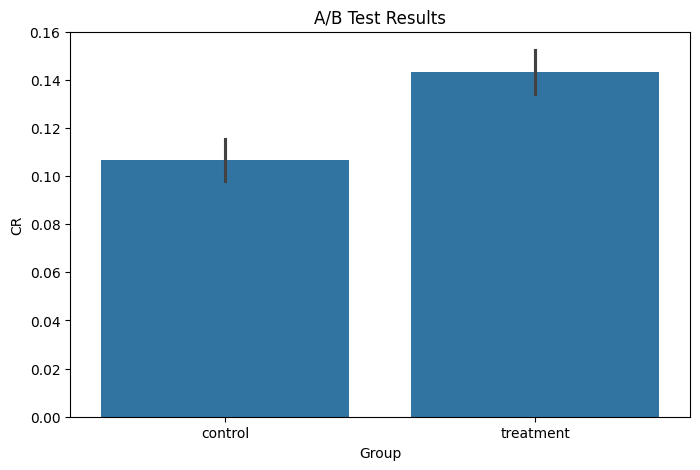

In [10]:
# @title
plt.figure(figsize=(8, 5))
sns.barplot(x=df['variant'],
            y=df['converted'],
            errorbar=('ci')) # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('CR')

plt.show()

##Test for average session duration

Average session duration by group and the difference between them.

In [11]:
print('Control Group Avg Session Duratin:', round(c_avg_sd, 6), ';', ' Control Group Variance:', round(df_gr.loc['control', 'var_session_duration'], 6))
print('Tteatment Group Avg Session Duratin:', round(t_avg_sd, 6), ';', ' Tteatment Group Variance:', round(df_gr.loc['treatment', 'var_session_duration'], 6))
lift_abs1 = t_avg_sd - c_avg_sd
lift_rel1 = lift_abs1 / c_avg_sd
print(f"absolute lift = {lift_abs1:.6f}, relative lift = {round(100 * lift_rel1, 2)}%")

Control Group Avg Session Duratin: 5.028694 ;  Control Group Variance: 3.865989
Tteatment Group Avg Session Duratin: 7.018729 ;  Tteatment Group Variance: 6.19907
absolute lift = 1.990035, relative lift = 39.57%


Checking for the presence of outliers.

In [25]:
df['round_sd'] = round(df['session_duration'])
df_sd_gr = df.groupby(['variant', 'round_sd']).size()
df_sd_gr = df_sd_gr.rename('sessions_count')
df_sd_gr = df_sd_gr.rename_axis(index={'round_sd' : 'round_session_duration'})
# df_sd_gr.names = ['variant', 'round_session_duration']
print(df_sd_gr)

variant    round_session_duration
control    1.0                        199
           2.0                        322
           3.0                        616
           4.0                        844
           5.0                       1050
           6.0                        848
           7.0                        587
           8.0                        331
           9.0                        154
           10.0                        44
           11.0                        15
           12.0                         2
           13.0                         1
treatment  1.0                         67
           2.0                        108
           3.0                        225
           4.0                        408
           5.0                        568
           6.0                        702
           7.0                        782
           8.0                        750
           9.0                        548
           10.0                       422


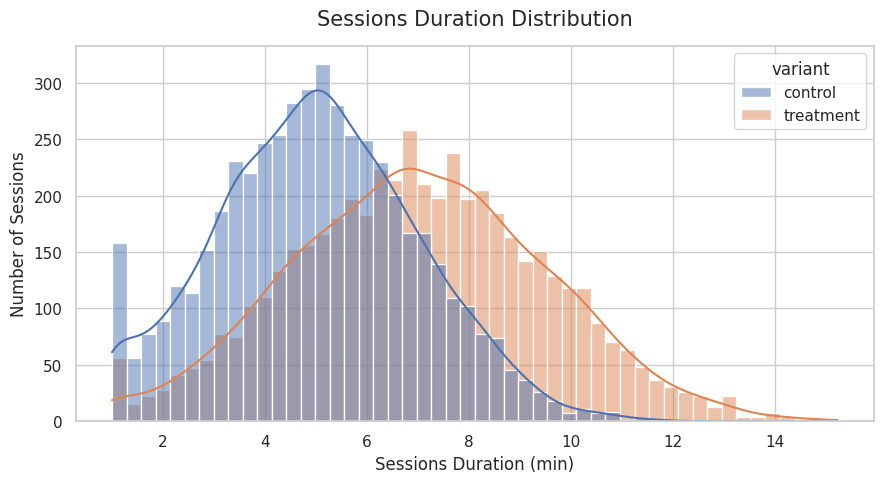

In [13]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

plot = sns.histplot(data=df, x='session_duration', hue='variant', kde=True, color='#1a73e8', bins=50)

plt.title('Sessions Duration Distribution', fontsize=15, pad=15)
plt.xlabel('Sessions Duration (min)', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# upper_limit = df['session_duration'].quantile(0.95)
# plt.xlim(0, upper_limit)

plt.tight_layout()
plt.show()

Analysis of the session duration frequency distribution (ranging from 1 to 15 minutes) confirms the absence of technical outliers or extreme anomalies. The data follows a natural right-skewed pattern, which is typical for user engagement metrics, and is suitable for further statistical testing. With a sample size of ~5,000, the Central Limit Theorem (CLT) guarantees that the sampling distribution of the average is close to normal, even if the raw data is slightly skewed. The group variances differ significantly (observed variances are 3.86 vs. 6.19). To test the hypothesis of an increase in average session duration, a one-tailed independent samples t-test with unequal variances (Welch’s t-test) should be used.

In [14]:

alpha = 0.05

statistic, pvalue = stats.ttest_ind(df[df['variant'] == 'control']['session_duration'],
                                    df[df['variant'] == 'treatment']['session_duration'],
                                    equal_var=False,
                                    alternative='less')

print(f't-statistic: {round(statistic, 2)}, p-value: {pvalue:.8f}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

t-statistic: -44.34, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


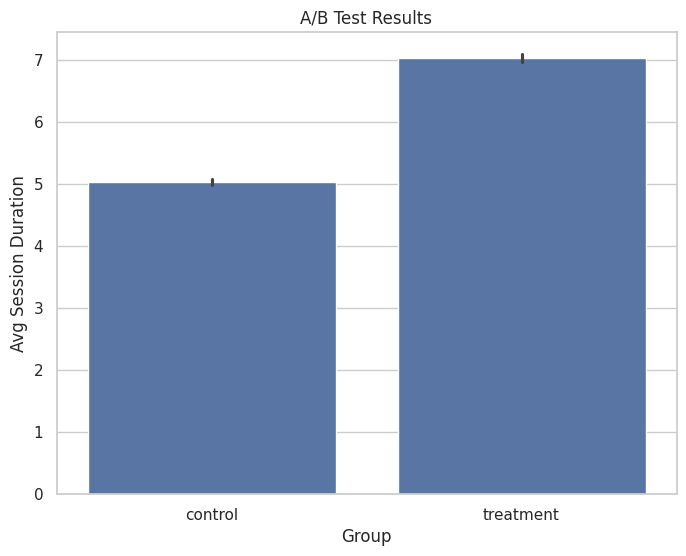

In [15]:
plt.figure(figsize=(8, 6))
sns.barplot(x=df['variant'],
            y=df['session_duration'],
            errorbar=('ci', 95)) # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Avg Session Duration')

plt.show()

##Test for average number of pages visited per session.

Average number of pages visited by group and the difference between them.

In [16]:
print('Control Group Avg Visited Pages:', round(c_avg_pv, 1), ';', ' Control Group Variance:', round(df_gr.loc['control', 'var_pages_visited'], 1))
print('Tteatment Group Avg Visited Pages:', round(t_avg_pv, 1), ';', ' Tteatment Group Variance:', round(df_gr.loc['treatment', 'var_pages_visited'], 1))
lift_abs2 = t_avg_pv - c_avg_pv
lift_rel2 = lift_abs2 / c_avg_pv
print(f"absolute lift = {lift_abs2:.1f}, relative lift = {round(100 * lift_rel2, 2)}%")

Control Group Avg Visited Pages: 3.0 ;  Control Group Variance: 2.9
Tteatment Group Avg Visited Pages: 5.0 ;  Tteatment Group Variance: 5.0
absolute lift = 2.0, relative lift = 68.1%


Checking for the presence of outliers.

In [17]:
df_pv_gr = df.groupby(['variant', 'pages_visited']).size()
df_pv_gr = df_pv_gr.rename('sessions_count')
# df_sd_gr = df_sd_gr.rename_axis(index={'round_sd' : 'round_session_duration'})
print(df_pv_gr)

variant    pages_visited
control    0                 241
           1                 734
           2                1140
           3                1170
           4                 857
           5                 474
           6                 241
           7                 104
           8                  38
           9                   7
           10                  7
treatment  0                  27
           1                 167
           2                 434
           3                 685
           4                 872
           5                 879
           6                 744
           7                 491
           8                 349
           9                 181
           10                 97
           11                 35
           12                 18
           13                  6
           14                  2
Name: sessions_count, dtype: int64


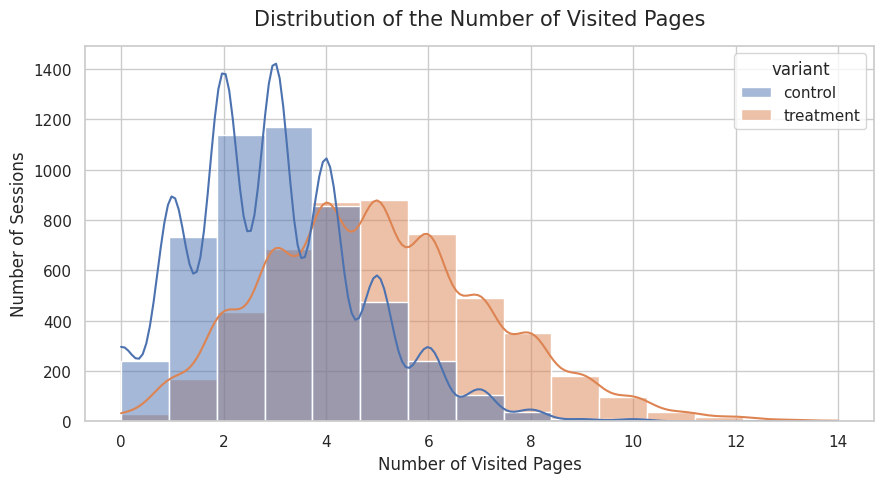

In [18]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

plot = sns.histplot(data=df, x='pages_visited', hue='variant', kde=True, color='#1a73e8', bins=15)

plt.title('Distribution of the Number of Visited Pages', fontsize=15, pad=15)
plt.xlabel('Number of Visited Pages', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

plt.tight_layout()
plt.show()

Analysis of the session duration frequency distribution (ranging from 0 to 14 pages) confirms the absence of technical outliers or extreme anomalies. The data follows a natural right-skewed pattern, which is typical for user engagement metrics, and is suitable for further statistical testing. With a sample size of ~5,000, the Central Limit Theorem (CLT) guarantees that the sampling distribution of the average is close to normal, even if the raw data is slightly skewed. The group variances differ significantly (observed variances are 2.9 vs. 5.0). To test the hypothesis of an increase in average number of pages visited, a one-tailed independent samples t-test with unequal variances (Welch’s t-test) should be used.

In [19]:

alpha = 0.05

statistic, pvalue = stats.ttest_ind(df[df['variant'] == 'control']['pages_visited'],
                                    df[df['variant'] == 'treatment']['pages_visited'],
                                    equal_var=False,
                                    alternative='less')

print(f't-statistic: {round(statistic, 2)}, p-value: {pvalue:.8f}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

t-statistic: -51.26, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


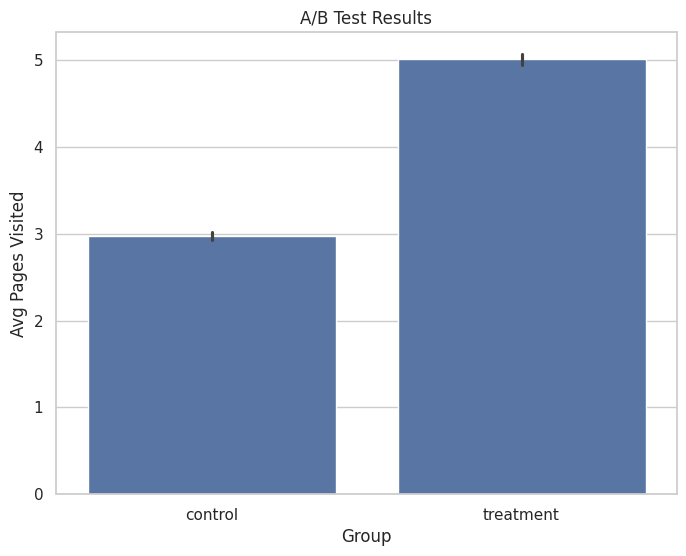

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(x=df['variant'],
            y=df['pages_visited'],
            errorbar=('ci', 95)) # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Avg Pages Visited')

plt.show()

#User segmentation by age groups

Creating of DataFrames for each age group.

In [33]:
# @title
print("Number of users per group:")
df25 = df[df['age'] < 25]
print('age <25:', df25.shape[0])
df25_34 = df[(df['age'] >= 25) & (df['age'] <= 34)]
print('age 25 - 34:', df25_34.shape[0])
df35_44 = df[(df['age'] >= 35) & (df['age'] <= 44)]
print('age 35 - 44:', df35_44.shape[0])
df45 = df[df['age'] >= 45]
print('age >44:', df45.shape[0])

Number of users per group:
age <25: 1453
age 25 - 34: 2220
age 35 - 44: 2173
age >44: 4154


In [34]:
# @title

dict_df = {
    'Age < 25' : df25,
    'Age 25 - 34' : df25_34,
    'Age 35 - 44' : df35_44,
    'Age 44+' : df45
  }

alpha = 0.05

def t_test(col):
  print('\n\n', f"t-test result for {col[1]}")
  statistic, p_value = stats.ttest_ind(ldf[ldf['variant'] == 'control'][col[0]],
                                    ldf[ldf['variant'] == 'treatment'][col[0]],
                                    equal_var=False,
                                    alternative='less')

  print("----------------------------------------")
  print(f't-statistic: {round(statistic, 2)}, p-value: {p_value:.8f}')
  print_result(p_value)


def print_result(p_value):
  if p_value < alpha:
      print('The difference is statistically significant, Null Hypothesis is rejected.')
  else:
      print('The difference is insignificant, Null Hypothesis cannot rejected.')


#calculate metrics, conduct z- and t-tests for each age group
for key, ldf in dict_df.items():
  print('\n', key)
  print('number of users:', ldf.shape[0])
  ldf_gr = ldf.groupby('variant').agg({'variant':'count',
                                   'converted':'sum',
                                   'session_duration':['mean', 'var'],
                                   'pages_visited':['mean', 'var'],
                                   'age':'mean'
                                  })
  ldf_gr.columns = ['group_count', 'conversions', 'avg_session_duration', 'var_session_duration', 'avg_pages_visited', 'var_pages_visited', 'avg_age']
  ldf_gr['cr'] = ldf_gr['conversions'] / ldf_gr['group_count']
  display(ldf_gr)

  print('\n\n', 'Z-test result for CR')

  count = np.array([ldf_gr.loc['control', 'conversions'], ldf_gr.loc['treatment', 'conversions']])
  nobs = np.array([ldf_gr.loc['control', 'group_count'], ldf_gr.loc['treatment', 'group_count']])


  z_stat, p_value = proportions_ztest(count,
                                      nobs,
                                      alternative='smaller')

  print("----------------------------------------")
  print(f"Z-statistic: {z_stat:.4f}")
  print(f"p-value: {p_value:.8f}")

  print_result(p_value)

  # cols = [['session_duration', 'тривалості сесії'], ['pages_visited', 'кількості відвіданих сторінок']]
  cols = [['session_duration', 'session_duration'], ['pages_visited', 'number of pages_visited']]

  for col in cols:
    t_test(col)

  print('-----------------------------------------------------------------------------------------------------------------------------------------')
  print(150 * '-')



 Age < 25
number of users: 1453


,group_count,conversions,avg_session_duration,var_session_duration,avg_pages_visited,var_pages_visited,avg_age,cr
variant,,,,,,,,
control,738,73,5.059546,3.757986,2.947154,2.774680,20.981030,0.098916
treatment,715,105,6.980870,6.736585,4.930070,4.653366,21.013986,0.146853




 Z-test result for CR
----------------------------------------
Z-statistic: -2.7863
p-value: 0.00266603
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for session_duration
----------------------------------------
t-statistic: -15.95, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for number of pages_visited
----------------------------------------
t-statistic: -19.57, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.
-----------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

 Age 25 - 34
number of users: 2220


,group_count,conversions,avg_session_duration,var_session_duration,avg_pages_visited,var_pages_visited,avg_age,cr
variant,,,,,,,,
control,1079,122,5.021787,3.827201,2.980538,2.963443,29.618165,0.113068
treatment,1141,152,7.078861,6.259476,4.844873,4.669774,29.658195,0.133216




 Z-test result for CR
----------------------------------------
Z-statistic: -1.4426
p-value: 0.07457265
The difference is insignificant, Null Hypothesis cannot rejected.


 t-test result for session_duration
----------------------------------------
t-statistic: -21.64, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for number of pages_visited
----------------------------------------
t-statistic: -22.54, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.
-----------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

 Age 35 - 44
number of users: 2173


,group_count,conversions,avg_session_duration,var_session_duration,avg_pages_visited,var_pages_visited,avg_age,cr
variant,,,,,,,,
control,1075,111,5.031442,3.969319,2.956279,2.831420,39.538605,0.103256
treatment,1098,170,7.052419,5.946430,5.050091,4.990196,39.408925,0.154827




 Z-test result for CR
----------------------------------------
Z-statistic: -3.5820
p-value: 0.00017047
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for session_duration
----------------------------------------
t-statistic: -21.18, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for number of pages_visited
----------------------------------------
t-statistic: -24.71, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.
-----------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

 Age 44+
number of users: 4154


,group_count,conversions,avg_session_duration,var_session_duration,avg_pages_visited,var_pages_visited,avg_age,cr
variant,,,,,,,,
control,2121,228,5.02008,3.875948,3.000471,2.873113,54.359736,0.107496
treatment,2033,288,6.98010,6.117213,5.102804,5.190706,54.536645,0.141663




 Z-test result for CR
----------------------------------------
Z-statistic: -3.3374
p-value: 0.00042279
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for session_duration
----------------------------------------
t-statistic: -28.18, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.


 t-test result for number of pages_visited
----------------------------------------
t-statistic: -33.63, p-value: 0.00000000
The difference is statistically significant, Null Hypothesis is rejected.
-----------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------


The increases across all metrics for each age group are statistically significant, with the exception of the 2% absolute uplift in conversion rate within the 25–34 age group. However, this lack of significance is due to the small sample size, which resulted in insufficient statistical power to detect this specific effect.

####**Key Findings:**
The new design had a positive impact on user conversion, increasing it from 10% to 14%. Additionally, an increase in mean session duration and the average number of pages visited was recorded.